# Влияние параметра Weibull k

В этом ноутбуке исследуется влияние параметра `weibull_shape = k` на развитие электрического пробоя.

Для каждого значения `k` используется один и тот же набор:

- `disorder_seed` — различные реализации материала;
- `random_seed` — различные стохастические траектории роста.

Таким образом, для каждого набора физических параметров оценивается статистика по ансамблю реализаций материала и траекторий роста.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace

from src.config import SimulationConfig
from src.simulator import run_simulation

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5,
    mean_breakdown_field=3.0,
    max_growth_steps=5000,
)

k_values = [2.0, 3.0, 5.0, 8.0, 15.0]

disorder_seeds = range(20)
random_seeds = range(10)

In [3]:
from tqdm.auto import tqdm

records = []

total_runs = (
    len(k_values)
    * len(disorder_seeds)
    * len(random_seeds)
)

with tqdm(total=total_runs) as pbar:
    for k in k_values:
        for disorder_seed in disorder_seeds:
            for random_seed in random_seeds:

                config = replace(
                    base_config,
                    weibull_shape=k,
                    disorder_seed=disorder_seed,
                    random_seed=random_seed,
                )

                field, history, breakdown = run_simulation(config)

                if breakdown:
                    status = "breakdown"
                elif len(history) == 0:
                    status = "no_start"
                elif len(history) >= config.max_growth_steps:
                    status = "max_steps"
                else:
                    status = "arrested"

                if np.any(field.channel):
                    max_y = int(
                        np.max(np.where(field.channel)[0])
                    )
                else:
                    max_y = 0

                height_fraction = max_y / (config.ny - 1)

                records.append(
                    {
                        "k": k,
                        "disorder_seed": disorder_seed,
                        "random_seed": random_seed,
                        "status": status,
                        "started": status != "no_start",
                        "breakdown": breakdown,
                        "steps": len(history),
                        "max_y": max_y,
                        "height_fraction": height_fraction,
                    }
                )

                pbar.update(1)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [4]:
results_df = pd.DataFrame(records)

print(results_df.shape)
results_df.head()
results_df.groupby("k").size()

(1000, 9)


k
2.0     200
3.0     200
5.0     200
8.0     200
15.0    200
dtype: int64

In [5]:
results_df.to_csv("weibull_k_results.csv", index=False)

In [6]:
summary = (
    results_df
    .groupby("k")
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n=("breakdown", "size"),
    )
)

p_breakdown_given_start = (
    results_df[results_df["started"]]
    .groupby("k")["breakdown"]
    .mean()
)

summary["p_breakdown_given_start"] = p_breakdown_given_start

summary

,p_start,p_breakdown,n,p_breakdown_given_start
k,,,,
2.0,0.70,0.47,200,0.671429
3.0,0.60,0.50,200,0.833333
5.0,0.60,0.55,200,0.916667
8.0,0.55,0.55,200,1.000000
15.0,0.35,0.35,200,1.000000


In [7]:
material_summary = (
    results_df
    .groupby(["k", "disorder_seed"])
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        mean_steps=("steps", "mean"),
        mean_height=("height_fraction", "mean"),
    )
    .reset_index()
)

material_summary.head()

,k,disorder_seed,p_start,p_breakdown,mean_steps,mean_height
0,2.0,0,1.0,0.0,50.3,0.19685
1,2.0,1,0.0,0.0,0.0,0.00000
2,2.0,2,1.0,1.0,487.1,1.00000
3,2.0,3,0.0,0.0,0.0,0.00000
4,2.0,4,1.0,1.0,504.3,1.00000


In [8]:
rng = np.random.default_rng(42)

def bootstrap_mean_ci(values, n_bootstrap=5000, confidence=0.95):
    values = np.asarray(values)

    bootstrap_means = []

    for _ in range(n_bootstrap):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )

        bootstrap_means.append(
            sample.mean()
        )

    alpha = 1 - confidence

    ci_low = np.quantile(
        bootstrap_means,
        alpha / 2,
    )

    ci_high = np.quantile(
        bootstrap_means,
        1 - alpha / 2,
    )

    return values.mean(), ci_low, ci_high

In [9]:
bootstrap_records = []

for k in k_values:
    values = material_summary.loc[
        material_summary["k"] == k,
        "p_breakdown",
    ].values

    mean, ci_low, ci_high = bootstrap_mean_ci(values)

    bootstrap_records.append(
        {
            "k": k,
            "p_breakdown": mean,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_records)

bootstrap_df

,k,p_breakdown,ci_low,ci_high
0,2.0,0.47,0.265000,0.675
1,3.0,0.50,0.289875,0.700
2,5.0,0.55,0.350000,0.750
3,8.0,0.55,0.350000,0.750
4,15.0,0.35,0.150000,0.550


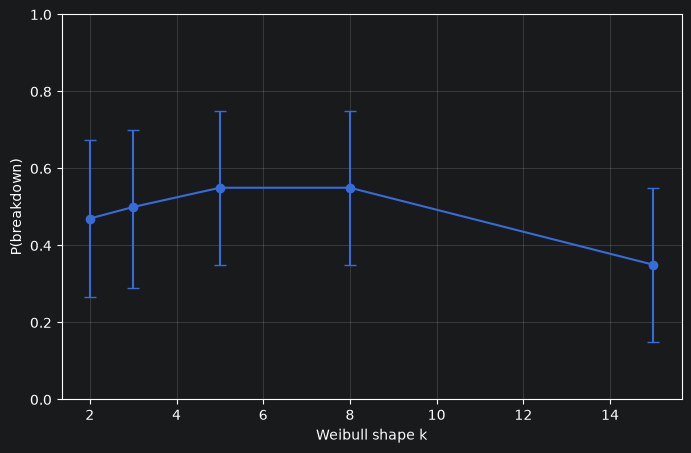

In [10]:
plt.figure(figsize=(8, 5))

yerr = np.vstack(
    [
        bootstrap_df["p_breakdown"] - bootstrap_df["ci_low"],
        bootstrap_df["ci_high"] - bootstrap_df["p_breakdown"],
    ]
)

plt.errorbar(
    bootstrap_df["k"],
    bootstrap_df["p_breakdown"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Weibull shape k")
plt.ylabel("P(breakdown)")
plt.ylim(0, 1)

plt.grid(alpha=0.3)

plt.show()

In [11]:
material_summary = (
    results_df
    .groupby(["k", "disorder_seed"])
    .agg(
        n_started=("started", "sum"),
        n_breakdown=("breakdown", "sum"),
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        mean_steps=("steps", "mean"),
        mean_height=("height_fraction", "mean"),
    )
    .reset_index()
)

material_summary["p_breakdown_given_start"] = (
    material_summary["n_breakdown"]
    / material_summary["n_started"]
)

material_summary.loc[
    material_summary["n_started"] == 0,
    "p_breakdown_given_start"
] = np.nan

material_summary.head()

,k,disorder_seed,n_started,n_breakdown,p_start,p_breakdown,mean_steps,mean_height,p_breakdown_given_start
0,2.0,0,10,0,1.0,0.0,50.3,0.19685,0.0
1,2.0,1,0,0,0.0,0.0,0.0,0.00000,NaN
2,2.0,2,10,10,1.0,1.0,487.1,1.00000,1.0
3,2.0,3,0,0,0.0,0.0,0.0,0.00000,NaN
4,2.0,4,10,10,1.0,1.0,504.3,1.00000,1.0


In [12]:
material_summary.to_csv(
    "material_summary.csv",
    index=False
)

In [13]:
rng = np.random.default_rng(42)

def bootstrap_probabilities(group, n_bootstrap=5000):
    n_random = len(random_seeds)

    estimates = []

    for _ in range(n_bootstrap):
        sample = group.sample(
            n=len(group),
            replace=True,
            random_state=int(rng.integers(0, 1_000_000_000)),
        )

        n_started = sample["n_started"].sum()
        n_breakdown = sample["n_breakdown"].sum()
        n_total = len(sample) * n_random

        p_start = n_started / n_total
        p_breakdown = n_breakdown / n_total

        if n_started > 0:
            p_breakdown_given_start = n_breakdown / n_started
        else:
            p_breakdown_given_start = np.nan

        estimates.append(
            [
                p_start,
                p_breakdown,
                p_breakdown_given_start,
            ]
        )

    estimates = np.array(estimates)

    return {
        "p_start": estimates[:, 0].mean(),
        "p_start_low": np.quantile(estimates[:, 0], 0.025),
        "p_start_high": np.quantile(estimates[:, 0], 0.975),

        "p_breakdown": estimates[:, 1].mean(),
        "p_breakdown_low": np.quantile(estimates[:, 1], 0.025),
        "p_breakdown_high": np.quantile(estimates[:, 1], 0.975),

        "p_breakdown_given_start": np.nanmean(estimates[:, 2]),
        "conditional_low": np.nanquantile(estimates[:, 2], 0.025),
        "conditional_high": np.nanquantile(estimates[:, 2], 0.975),
    }

In [14]:
bootstrap_results = []

for k in k_values:
    group = material_summary[
        material_summary["k"] == k
    ]

    result = bootstrap_probabilities(group)
    result["k"] = k

    bootstrap_results.append(result)

k_stats = pd.DataFrame(bootstrap_results)

k_stats

,p_start,p_start_low,p_start_high,p_breakdown,p_breakdown_low,p_breakdown_high,p_breakdown_given_start,conditional_low,conditional_high,k
0,0.70221,0.50,0.90,0.470490,0.255,0.675,0.669796,0.430769,0.888252,2.0
1,0.60068,0.40,0.80,0.501083,0.305,0.700,0.834300,0.669167,0.973375,3.0
2,0.59821,0.40,0.80,0.548560,0.350,0.750,0.916824,0.727273,1.000000,5.0
3,0.54818,0.35,0.75,0.548180,0.350,0.750,1.000000,1.000000,1.000000,8.0
4,0.35064,0.15,0.55,0.350640,0.150,0.550,1.000000,1.000000,1.000000,15.0


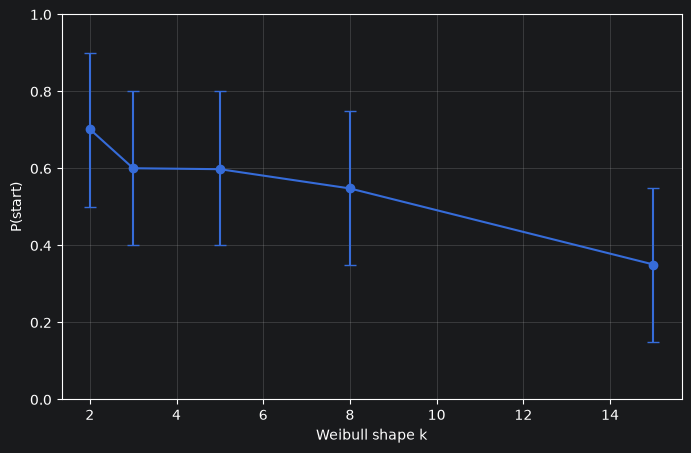

In [15]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    k_stats["p_start"] - k_stats["p_start_low"],
    k_stats["p_start_high"] - k_stats["p_start"],
])

plt.errorbar(
    k_stats["k"],
    k_stats["p_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Weibull shape k")
plt.ylabel("P(start)")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.show()

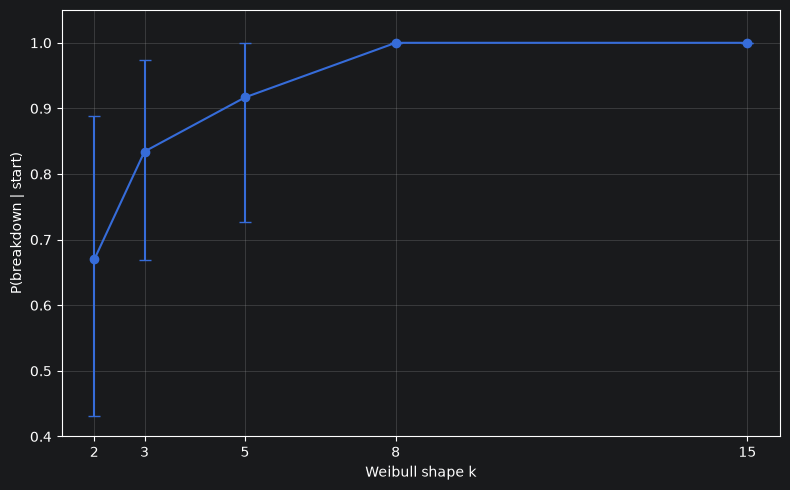

In [17]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    k_stats["p_breakdown_given_start"]
    - k_stats["conditional_low"],

    k_stats["conditional_high"]
    - k_stats["p_breakdown_given_start"],
])

plt.errorbar(
    k_stats["k"],
    k_stats["p_breakdown_given_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Weibull shape k")
plt.ylabel("P(breakdown | start)")

plt.xticks(k_stats["k"])
plt.ylim(0.4, 1.05)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [18]:
from scipy.stats import friedmanchisquare

pivot_start = material_summary.pivot(
    index="disorder_seed",
    columns="k",
    values="p_start",
)

stat, p_value = friedmanchisquare(
    *[
        pivot_start[k].values
        for k in k_values
    ]
)

print("Friedman statistic:", stat)
print("p-value:", p_value)

Friedman statistic: 17.866666666666788
p-value: 0.001310381151833786


### Статистическая проверка влияния k на старт пробоя

Для сравнения вероятности старта между разными значениями `k` использован критерий Фридмана, так как для всех значений `k` использовались одинаковые `disorder_seed`.

Получено:

$$
\chi_F^2 \approx 17.87,
$$

$$
p \approx 0.0013.
$$

Таким образом, гипотеза об одинаковой вероятности старта для всех значений `k` отвергается. Параметр Weibull `k` статистически значимо влияет на вероятность возникновения пробоя.

In [20]:
pairwise_results = []

for k1, k2 in combinations(k_values, 2):
    x = pivot_start[k1].values
    y = pivot_start[k2].values

    if np.allclose(x, y):
        stat = 0.0
        p_value = 1.0
    else:
        stat, p_value = wilcoxon(x, y)

    pairwise_results.append(
        {
            "k1": k1,
            "k2": k2,
            "mean_diff": np.mean(x - y),
            "p_value": p_value,
        }
    )

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df["p_adjusted"] = multipletests(
    pairwise_df["p_value"],
    method="holm",
)[1]

pairwise_df["significant"] = (
    pairwise_df["p_adjusted"] < 0.05
)

pairwise_df

,k1,k2,mean_diff,p_value,p_adjusted,significant
0,2.0,3.0,0.10,0.157299,0.786496,False
1,2.0,5.0,0.10,0.157299,0.786496,False
2,2.0,8.0,0.15,0.083265,0.499587,False
3,2.0,15.0,0.35,0.008151,0.081510,False
4,3.0,5.0,0.00,1.000000,1.000000,False
5,3.0,8.0,0.05,0.317311,0.951932,False
6,3.0,15.0,0.25,0.025347,0.228126,False
7,5.0,8.0,0.05,0.317311,0.951932,False
8,5.0,15.0,0.25,0.025347,0.228126,False
9,8.0,15.0,0.20,0.045500,0.318502,False


In [21]:
material_summary.groupby("k")[
    "p_breakdown_given_start"
].count()

k
2.0     14
3.0     12
5.0     12
8.0     11
15.0     7
Name: p_breakdown_given_start, dtype: int64

In [22]:
pivot_conditional = material_summary.pivot(
    index="disorder_seed",
    columns="k",
    values="p_breakdown_given_start",
)

complete_conditional = pivot_conditional.dropna()

print("Complete materials:", len(complete_conditional))

complete_conditional

Complete materials: 7


k,2.0,3.0,5.0,8.0,15.0
disorder_seed,,,,,
0,0.0,0.8,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0
5,0.9,1.0,1.0,1.0,1.0
8,1.0,1.0,1.0,1.0,1.0
13,0.5,1.0,1.0,1.0,1.0
15,1.0,1.0,1.0,1.0,1.0
17,1.0,1.0,1.0,1.0,1.0


### Вывод по параметру Weibull k

Параметр `k` влияет на развитие пробоя двумя различными способами.

С ростом `k` вероятность старта канала уменьшается. Критерий Фридмана показал статистически значимое общее влияние `k` на вероятность старта:

$$
p \approx 0.0013.
$$

Одновременно среди уже стартовавших каналов вероятность полного пробоя возрастает и при больших `k` приближается к единице.

Таким образом, более неоднородная среда облегчает появление локальных слабых областей и запуск канала, но может препятствовать его дальнейшему распространению. Более однородная среда, напротив, реже допускает старт, однако начавшийся канал с высокой вероятностью проходит через весь образец.

Для будущего датасета `k` является информативным физическим параметром и должен варьироваться при генерации данных.